# 06. 장애인콜택시 예상 대기시간 모델 개선 실험

목적: `05_calltaxi_wait_time_modeling.ipynb`에서 만든 1차 RandomForest 모델의 한계를 보완하기 위해 추가 피처와 후처리 기준을 실험한다.

기준 모델 성능:

```text
모델: RandomForestRegressor
학습: train + validation
평가: test set
MAE = 16.48분
RMSE = 25.49분
R² = 0.499
장시간 대기 기준 = 접수→승차 90분위수, 약 94.15분
Recall = 0.334
F1 = 0.467
```

현재 모델은 Baseline보다 성능이 개선되었지만, 장시간 대기 탐지 Recall이 낮다. 06번 노트북에서는 다음 개선 방향을 확인한다.

1. 장시간 대기 경고 threshold 조정
2. 이전 30분/1시간 접수량 피처 추가
3. 출발구별 수요 집중도 피처 추가
4. 취소율/장시간 대기율 proxy 피처 검토
5. 필요 시 HistGradientBoostingRegressor 비교

주의:

- test set은 최종 비교용으로만 사용한다.
- 피처를 만들 때 예측 시점 이후 정보가 들어가지 않도록 target leakage를 피한다.
- `승차일시`, `배차일시`, `접수_승차_분`처럼 결과를 알게 된 뒤 생성되는 값은 모델 입력 피처로 사용하지 않는다.


In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import ParameterSampler, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks_waiting_time" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models" / "waiting_time"
REPORT_DIR = PROJECT_ROOT / "reports" / "waiting_time_model"

RENTAL_PATH = DATA_DIR / "임차택시_대기시간_전처리.csv"
SPECIAL_PATH = DATA_DIR / "특장차_대기시간_전처리_접수유형분류.csv"

RENTAL_PATH, SPECIAL_PATH

(PosixPath('/Users/blaumonde/calltaxi-DA/data/processed/임차택시_대기시간_전처리.csv'),
 PosixPath('/Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류.csv'))

## 1. 공통 함수

05번 노트북과 동일한 기준으로 모델링 데이터를 만든다. 06번에서는 추가 피처 실험을 위해 `이용목적`, `배차일시`, `취소일시` 등 후보 컬럼도 함께 보관한다.


In [2]:
def load_modeling_dataset_for_experiments(extreme_wait_threshold=180.0):
    rental_cols = [
        "접수일시", "배차일시", "승차일시", "취소일시",
        "출발구", "출발동", "목적구", "목적동", "이용목적", "차량구분", "장애유형",
        "접수_배차_분", "배차_승차_분", "접수_승차_분", "접수_취소_분", "배차_취소_분",
        "임차택시_바로콜여부", "대기시간분석_포함여부",
    ]
    special_cols = [
        "접수일시", "배차일시", "승차일시", "취소일시",
        "출발구", "출발동", "목적구", "목적동", "이용목적", "차량구분", "장애유형",
        "접수_배차_분", "배차_승차_분", "접수_승차_분", "접수_취소_분", "배차_취소_분",
        "특장차_바로콜_후보여부", "특장차_접수유형_후보_최종",
    ]

    rental = pd.read_csv(RENTAL_PATH, usecols=rental_cols, low_memory=False)
    rental = rental[
        rental["임차택시_바로콜여부"].fillna(False).astype(bool)
        & rental["대기시간분석_포함여부"].fillna(False).astype(bool)
    ].copy()
    rental["model_group"] = "임차택시_바로콜"

    special = pd.read_csv(SPECIAL_PATH, usecols=special_cols, low_memory=False)
    special = special[
        special["특장차_바로콜_후보여부"].fillna(False).astype(bool)
        | special["특장차_접수유형_후보_최종"].eq("바로콜 후보")
    ].copy()
    special["model_group"] = "특장차_바로콜"

    keep_cols = [
        "model_group", "접수일시", "배차일시", "승차일시", "취소일시",
        "출발구", "출발동", "목적구", "목적동", "이용목적", "차량구분", "장애유형",
        "접수_배차_분", "배차_승차_분", "접수_승차_분", "접수_취소_분", "배차_취소_분",
    ]
    data = pd.concat([rental[keep_cols], special[keep_cols]], ignore_index=True)

    for col in ["접수일시", "배차일시", "승차일시", "취소일시"]:
        data[col] = pd.to_datetime(data[col], errors="coerce")

    for col in ["접수_배차_분", "배차_승차_분", "접수_승차_분", "접수_취소_분", "배차_취소_분"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    data = data[
        data["접수일시"].notna()
        & data["승차일시"].notna()
        & data["접수_승차_분"].notna()
        & data["접수_승차_분"].ge(0)
    ].copy()

    data["target_min"] = data["접수_승차_분"]
    data["is_extreme_wait"] = data["접수_승차_분"].gt(extreme_wait_threshold).astype("int8")

    data["hour"] = data["접수일시"].dt.hour.astype("int16")
    data["dayofweek"] = data["접수일시"].dt.dayofweek.astype("int16")
    data["month"] = data["접수일시"].dt.month.astype("int16")
    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype("int8")
    data["is_night"] = data["hour"].between(0, 6, inclusive="both").astype("int8")
    data["is_commute"] = (
        data["hour"].between(7, 9, inclusive="both")
        | data["hour"].between(17, 19, inclusive="both")
    ).astype("int8")
    data["season"] = data["month"].map({
        12: "겨울", 1: "겨울", 2: "겨울",
        3: "봄", 4: "봄", 5: "봄",
        6: "여름", 7: "여름", 8: "여름",
        9: "가을", 10: "가을", 11: "가을",
    })

    for col in ["출발구", "출발동", "목적구", "목적동", "이용목적", "차량구분", "장애유형", "season"]:
        data[col] = data[col].fillna("미상").astype(str)

    return data

data = load_modeling_dataset_for_experiments()
data.shape

(1404813, 26)

In [3]:
data[[
    "model_group", "접수일시", "출발구", "목적구", "이용목적",
    "target_min", "hour", "dayofweek", "month", "is_extreme_wait"
]].head()

,model_group,접수일시,출발구,목적구,이용목적,target_min,hour,dayofweek,month,is_extreme_wait
0,임차택시_바로콜,2025-01-01 05:56:10.000,강동구,강동구,치료,140.833333,5,2,1,0
1,임차택시_바로콜,2025-01-01 03:55:00.983,성북구,성북구,치료,199.983617,3,2,1,1
2,임차택시_바로콜,2025-01-01 06:27:42.000,서초구,노원구,기타,122.300000,6,2,1,0
3,임차택시_바로콜,2025-01-01 07:15:29.733,강동구,강동구,기타,89.504450,7,2,1,0
4,임차택시_바로콜,2025-01-01 08:45:22.857,강동구,하남시,기타,59.619050,8,2,1,0


## 2. 기존 1차 모델 기준 재현

05번 노트북과 동일하게 월 × model_group 기준 층화 랜덤 분리를 사용한다.


In [4]:
def split_train_valid_test(data):
    data = data.copy()
    data["split_strata"] = data["month"].astype(str) + "_" + data["model_group"].astype(str)

    train, temp = train_test_split(
        data,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=data["split_strata"],
    )
    valid, test = train_test_split(
        temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=temp["split_strata"],
    )

    for frame in [train, valid, test]:
        frame.drop(columns=["split_strata"], inplace=True)

    return train.reset_index(drop=True), valid.reset_index(drop=True), test.reset_index(drop=True)

train, valid, test = split_train_valid_test(data)
train.shape, valid.shape, test.shape

((983369, 26), (210722, 26), (210722, 26))

In [5]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "Median_AE": median_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def risk_metrics(y_true, y_pred, threshold):
    actual = y_true >= threshold
    pred = y_pred >= threshold
    return {
        "threshold": threshold,
        "Accuracy": accuracy_score(actual, pred),
        "Precision": precision_score(actual, pred, zero_division=0),
        "Recall": recall_score(actual, pred, zero_division=0),
        "F1": f1_score(actual, pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(actual, pred, labels=[False, True]).tolist(),
    }


def evaluate_predictions(frame, pred, threshold):
    y = frame["target_min"].to_numpy()
    return {
        **regression_metrics(y, pred),
        **{f"risk_{k}": v for k, v in risk_metrics(y, pred, threshold).items()},
    }


def evaluate_by_group(frame, pred, threshold_by_group):
    tmp = frame[["model_group", "target_min"]].copy()
    tmp["prediction"] = pred
    rows = []
    for group, group_df in tmp.groupby("model_group"):
        y = group_df["target_min"].to_numpy()
        p = group_df["prediction"].to_numpy()
        threshold = threshold_by_group[group]
        rows.append({
            "model_group": group,
            "rows": len(group_df),
            **regression_metrics(y, p),
            **{f"risk_{k}": v for k, v in risk_metrics(y, p, threshold).items() if k != "Confusion_Matrix"},
        })
    return pd.DataFrame(rows)

## 3. Threshold 조정 실험

현재 1차 모델은 장시간 대기 기준을 train set의 90분위수로 사용했다. 이 기준은 Precision은 높지만 Recall이 낮았다. 네비게이터에서 장시간 대기 위험을 더 적극적으로 안내하려면 예측값 threshold를 낮춰 Precision/Recall trade-off를 확인해야 한다.

이 섹션은 05번에서 학습한 `final_model`과 `test_pred`를 그대로 사용할 수도 있고, 아래에서 다시 모델을 학습한 뒤 사용할 수도 있다.


In [6]:
BASE_FEATURES = [
    "model_group", "출발구", "목적구",
    "hour", "dayofweek", "month", "is_weekend", "is_night", "is_commute",
]

best_rf_params = {
    "n_estimators": 50,
    "min_samples_leaf": 20,
    "max_features": 1.0,
    "max_depth": 18,
}


def build_rf_pipeline(feature_cols, params=None):
    categorical_cols = [c for c in ["model_group", "출발구", "목적구", "이용목적", "차량구분", "장애유형"] if c in feature_cols]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,
            ), categorical_cols),
            ("num", "passthrough", numeric_cols),
        ],
        verbose_feature_names_out=False,
    )

    default_params = {
        "n_estimators": 50,
        "max_depth": 18,
        "min_samples_leaf": 20,
        "max_features": 1.0,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbose": 1,
    }
    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(**default_params)),
    ])

train_valid = pd.concat([train, valid], ignore_index=True)

rf_base_model = build_rf_pipeline(BASE_FEATURES, best_rf_params)
rf_base_model.fit(train_valid[BASE_FEATURES], train_valid["target_min"])

test_pred_base_rf = rf_base_model.predict(test[BASE_FEATURES])

long_wait_threshold = train["target_min"].quantile(0.90)
threshold_by_group = train.groupby("model_group")["target_min"].quantile(0.90).to_dict()

evaluate_predictions(test, test_pred_base_rf, long_wait_threshold)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   24.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.3s finished


{'MAE': 16.483884074729804,
 'Median_AE': 10.787399649014343,
 'RMSE': np.float64(25.48641061442379),
 'R2': 0.49879260617146115,
 'risk_threshold': np.float64(94.14695333333344),
 'risk_Accuracy': 0.9249152912367954,
 'risk_Precision': 0.7742585338556239,
 'risk_Recall': 0.3338319741350191,
 'risk_F1': 0.4665183087194012,
 'risk_Confusion_Matrix': [[187982, 2017], [13805, 6918]]}

In [7]:
def threshold_sweep(y_true, y_pred, thresholds):
    rows = []
    for threshold in thresholds:
        m = risk_metrics(y_true, y_pred, threshold)
        rows.append({
            "prediction_threshold": threshold,
            "Accuracy": m["Accuracy"],
            "Precision": m["Precision"],
            "Recall": m["Recall"],
            "F1": m["F1"],
            "Confusion_Matrix": m["Confusion_Matrix"],
        })
    return pd.DataFrame(rows)

threshold_candidates = [70, 75, 80, 85, 90, float(long_wait_threshold)]
threshold_results = threshold_sweep(
    test["target_min"].to_numpy(),
    test_pred_base_rf,
    threshold_candidates,
)

display(threshold_results.round(4))

,prediction_threshold,Accuracy,Precision,Recall,F1,Confusion_Matrix
0,70.000,0.8747,0.6863,0.5296,0.5979,"[[164674, 8974], [17439, 19635]]"
1,75.000,0.8856,0.6935,0.4772,0.5654,"[[170929, 6932], [17179, 15682]]"
2,80.000,0.8966,0.7082,0.4306,0.5356,"[[176380, 5174], [16608, 12560]]"
3,85.000,0.9064,0.7295,0.3868,0.5056,"[[180927, 3737], [15978, 10080]]"
4,90.000,0.9153,0.7529,0.3498,0.4777,"[[184708, 2679], [15172, 8163]]"
5,94.147,0.9249,0.7743,0.3338,0.4665,"[[187982, 2017], [13805, 6918]]"


In [10]:
def prediction_threshold_sweep_fixed_actual(y_true, y_pred, actual_threshold, prediction_thresholds):
    rows = []

    actual = y_true >= actual_threshold

    for pred_threshold in prediction_thresholds:
        pred = y_pred >= pred_threshold

        rows.append({
            "actual_threshold": actual_threshold,
            "prediction_threshold": pred_threshold,
            "Accuracy": accuracy_score(actual, pred),
            "Precision": precision_score(actual, pred, zero_division=0),
            "Recall": recall_score(actual, pred, zero_division=0),
            "F1": f1_score(actual, pred, zero_division=0),
            "Confusion_Matrix": confusion_matrix(actual, pred, labels=[False, True]).tolist(),
        })

    return pd.DataFrame(rows)


actual_long_wait_threshold = long_wait_threshold

prediction_threshold_candidates = [70, 75, 80, 85, 90, float(long_wait_threshold)]

fixed_actual_threshold_results = prediction_threshold_sweep_fixed_actual(
    test["target_min"].to_numpy(),
    test_pred_base_rf,
    actual_threshold=actual_long_wait_threshold,
    prediction_thresholds=prediction_threshold_candidates,
)

display(fixed_actual_threshold_results.round(4))

,actual_threshold,prediction_threshold,Accuracy,Precision,Recall,F1,Confusion_Matrix
0,94.147,70.000,0.8875,0.4478,0.6183,0.5194,"[[174202, 15797], [7911, 12812]]"
1,94.147,75.000,0.9035,0.5088,0.5552,0.5310,"[[178891, 11108], [9217, 11506]]"
2,94.147,80.000,0.9147,0.5776,0.4943,0.5328,"[[182509, 7490], [10479, 10244]]"
3,94.147,85.000,0.9214,0.6506,0.4338,0.5206,"[[185172, 4827], [11733, 8990]]"
4,94.147,90.000,0.9245,0.7216,0.3776,0.4957,"[[186981, 3018], [12899, 7824]]"
5,94.147,94.147,0.9249,0.7743,0.3338,0.4665,"[[187982, 2017], [13805, 6918]]"


## 4. 이용목적 보조 피처 실험

`이용목적`은 `기타` 비중이 매우 높아 핵심 피처로 기대하기는 어렵다. 다만 치료·재활 목적 여부를 보조 피처로 추가했을 때 성능이 개선되는지 확인할 수 있다.


In [8]:
medical_purpose_values = [
    "치료", "예약치료", "치료광역",
    "재활", "예약재활",
]

for frame in [train, valid, test]:
    frame["is_medical_or_rehab_purpose"] = frame["이용목적"].isin(medical_purpose_values).astype("int8")

purpose_summary = (
    train["이용목적"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
purpose_summary.columns = ["이용목적", "비율(%)"]
display(purpose_summary.head(20))

train["is_medical_or_rehab_purpose"].mean() * 100

,이용목적,비율(%)
0,기타,82.04
1,귀가,7.95
2,치료,6.21
3,재활,2.15
4,통학/출근,1.12
5,종교,0.41
6,치료광역,0.09
7,공항티켓,0.02
8,쇼핑,0.01
9,예약기타,0.00


np.float64(8.454506904325843)

## 5. 수요 proxy 피처 설계 메모

다음 단계에서 추가할 후보:

```text
request_count_prev_30m
request_count_prev_60m
model_group_request_count_prev_60m
origin_gu_request_count_prev_60m
origin_gu_hour_long_wait_rate
model_group_hour_cancel_rate
```

주의: rolling count는 반드시 접수시각 이전 데이터만 사용해야 한다. 전체 데이터를 한 번에 집계한 시간대 평균은 해석용으로는 가능하지만, 예측 시점 이후 정보를 포함하면 target leakage가 될 수 있다.

| 피처 | 의미 | 기대 효과 |
|---|---|---|
| `request_count_prev_30m` | 해당 접수시각 이전 30분 동안 전체 접수건수 | 직전 전체 수요 집중도 반영 |
| `request_count_prev_60m` | 해당 접수시각 이전 1시간 동안 전체 접수건수 | 직전 전체 수요 흐름 반영 |
| `model_group_request_count_prev_60m` | 같은 차량·호출유형에서 이전 1시간 동안 접수된 건수 | 임차택시/특장차별 수요 집중도 반영 |
| `origin_gu_request_count_prev_60m` | 같은 출발구에서 이전 1시간 동안 접수된 건수 | 출발 지역별 수요 집중도 반영 |
| `origin_gu_hour_long_wait_rate` | 출발구·시간대별 장시간 대기 비율 | 특정 지역·시간대의 반복적 장시간 대기 위험 반영 |
| `model_group_hour_cancel_rate` | 차량·호출유형·시간대별 취소율 | 특정 시간대의 서비스 이탈 위험 반영 |


In [9]:
# TODO: 이전 30분/1시간 접수량 피처 생성
# 구현 방향:
# 1. 접수일시 기준 정렬
# 2. 전체/model_group/출발구 단위 rolling count 계산
# 3. train/valid/test split 이전에 계산하되, 각 행의 접수시각 이전 건만 카운트

# 다음 셀에서 구현 예정

## 5-1. 전체 이전 30분/60분 접수량 피처 생성

```text
목적:
각 접수건 기준으로, 해당 접수시각 이전 30분/60분 동안
전체 바로콜 접수가 얼마나 있었는지 계산한다.

주의:
현재 행의 접수건은 포함하지 않는다.
접수시각 이후 데이터는 사용하지 않는다.

In [13]:
def add_global_previous_request_counts(
    frame,
    time_col="접수일시",
    windows=("30min", "60min"),
):
    result = frame.copy()

    # 원래 순서를 보존하기 위한 index
    result["_original_index"] = np.arange(len(result))

    # 접수시각 기준 정렬
    result = result.sort_values(time_col).copy()

    # rolling count 계산용 dummy
    result["_request_count"] = 1

    # DatetimeIndex 기반 rolling 계산
    temp = result.set_index(time_col)

    for window in windows:
        col_name = f"request_count_prev_{window.replace('min', 'm')}"

        # closed="left":
        # 현재 접수시각의 자기 자신은 제외하고,
        # 현재 시각 이전 window 안에 있는 접수건만 카운트
        result[col_name] = (
            temp["_request_count"]
            .rolling(window=window, closed="left")
            .sum()
            .fillna(0)
            .to_numpy()
        )

    # 원래 순서로 복원
    result = result.sort_values("_original_index").drop(
        columns=["_original_index", "_request_count"]
    )

    return result


data_with_demand = add_global_previous_request_counts(data)

display(data_with_demand[[
    "접수일시",
    "model_group",
    "출발구",
    "목적구",
    "request_count_prev_30m",
    "request_count_prev_60m",
    "target_min",
]].head())

,접수일시,model_group,출발구,목적구,request_count_prev_30m,request_count_prev_60m,target_min
0,2025-01-01 05:56:10.000,임차택시_바로콜,강동구,강동구,6.0,13.0,140.833333
1,2025-01-01 03:55:00.983,임차택시_바로콜,성북구,성북구,3.0,4.0,199.983617
2,2025-01-01 06:27:42.000,임차택시_바로콜,서초구,노원구,4.0,10.0,122.300000
3,2025-01-01 07:15:29.733,임차택시_바로콜,강동구,강동구,3.0,6.0,89.504450
4,2025-01-01 08:45:22.857,임차택시_바로콜,강동구,하남시,20.0,33.0,59.619050


In [14]:
data_with_demand[[
    "request_count_prev_30m",
    "request_count_prev_60m",
]].describe().round(2)

,request_count_prev_30m,request_count_prev_60m
count,1404813.00,1404813.00
mean,189.23,371.31
std,98.24,191.12
min,0.00,0.00
25%,102.00,199.00
50%,204.00,392.00
75%,271.00,538.00
max,453.00,798.00


request_count_prev_30m:
내 호출 직전 30분 동안 전체 바로콜 접수건수

request_count_prev_60m:
내 호출 직전 60분 동안 전체 바로콜 접수건수

## 5-2. 차량·호출유형별 이전 60분 접수량 피처 생성

```text
내가 선택한 차량/호출유형에서 직전 1시간 동안 얼마나 호출이 몰렸는지 보는 피처

특장차_바로콜 직전 1시간 접수량
임차택시_바로콜 직전 1시간 접수량

In [15]:
def add_group_previous_request_counts(
    frame,
    group_col="model_group",
    time_col="접수일시",
    window="60min",
):
    result = frame.copy()
    result["_original_index"] = np.arange(len(result))

    count_col = f"{group_col}_request_count_prev_{window.replace('min', 'm')}"
    result[count_col] = 0.0

    pieces = []

    for group_value, group_df in result.groupby(group_col):
        group_df = group_df.sort_values(time_col).copy()
        group_df["_request_count"] = 1

        temp = group_df.set_index(time_col)

        group_df[count_col] = (
            temp["_request_count"]
            .rolling(window=window, closed="left")
            .sum()
            .fillna(0)
            .to_numpy()
        )

        pieces.append(group_df.drop(columns=["_request_count"]))

    result = (
        pd.concat(pieces, ignore_index=True)
        .sort_values("_original_index")
        .drop(columns=["_original_index"])
    )

    return result


data_with_demand = add_group_previous_request_counts(data_with_demand)

display(data_with_demand[[
    "접수일시",
    "model_group",
    "request_count_prev_60m",
    "model_group_request_count_prev_60m",
    "target_min",
]].head(10))

,접수일시,model_group,request_count_prev_60m,model_group_request_count_prev_60m,target_min
1,2025-01-01 05:56:10.000,임차택시_바로콜,13.0,0.0,140.833333
0,2025-01-01 03:55:00.983,임차택시_바로콜,4.0,0.0,199.983617
2,2025-01-01 06:27:42.000,임차택시_바로콜,10.0,1.0,122.300000
3,2025-01-01 07:15:29.733,임차택시_바로콜,6.0,1.0,89.504450
5,2025-01-01 08:45:22.857,임차택시_바로콜,33.0,0.0,59.619050
6,2025-01-01 09:09:54.100,임차택시_바로콜,37.0,1.0,47.098333
7,2025-01-01 09:12:53.497,임차택시_바로콜,33.0,2.0,63.357167
8,2025-01-01 09:39:19.110,임차택시_바로콜,56.0,3.0,40.767550
9,2025-01-01 09:39:40.300,임차택시_바로콜,57.0,4.0,24.984833
4,2025-01-01 07:35:00.103,임차택시_바로콜,8.0,1.0,170.620950


In [16]:
data_with_demand[[
    "request_count_prev_60m",
    "model_group_request_count_prev_60m",
]].describe().round(2)

,request_count_prev_60m,model_group_request_count_prev_60m
count,1404813.00,1404813.00
mean,371.31,238.21
std,191.12,143.54
min,0.00,0.00
25%,199.00,119.00
50%,392.00,214.00
75%,538.00,377.00
max,798.00,583.00


## 5-3. 출발구별 이전 60분 접수량 피처 생성

내 출발구에서 직전 1시간 동안 바로콜 접수가 얼마나 있었는가

In [17]:
def add_origin_gu_previous_request_counts(
    frame,
    origin_col="출발구",
    time_col="접수일시",
    window="60min",
):
    result = frame.copy()
    result["_original_index"] = np.arange(len(result))

    count_col = f"origin_gu_request_count_prev_{window.replace('min', 'm')}"
    result[count_col] = 0.0

    pieces = []

    for origin_value, group_df in result.groupby(origin_col):
        group_df = group_df.sort_values(time_col).copy()
        group_df["_request_count"] = 1

        temp = group_df.set_index(time_col)

        group_df[count_col] = (
            temp["_request_count"]
            .rolling(window=window, closed="left")
            .sum()
            .fillna(0)
            .to_numpy()
        )

        pieces.append(group_df.drop(columns=["_request_count"]))

    result = (
        pd.concat(pieces, ignore_index=True)
        .sort_values("_original_index")
        .drop(columns=["_original_index"])
    )

    return result


data_with_demand = add_origin_gu_previous_request_counts(data_with_demand)

display(data_with_demand[[
    "접수일시",
    "model_group",
    "출발구",
    "request_count_prev_60m",
    "model_group_request_count_prev_60m",
    "origin_gu_request_count_prev_60m",
    "target_min",
]].head(10))

,접수일시,model_group,출발구,request_count_prev_60m,model_group_request_count_prev_60m,origin_gu_request_count_prev_60m,target_min
52655,2025-01-01 05:56:10.000,임차택시_바로콜,강동구,13.0,0.0,1.0,140.833333
963586,2025-01-01 03:55:00.983,임차택시_바로콜,성북구,4.0,0.0,0.0,199.983617
892915,2025-01-01 06:27:42.000,임차택시_바로콜,서초구,10.0,1.0,0.0,122.300000
52657,2025-01-01 07:15:29.733,임차택시_바로콜,강동구,6.0,1.0,0.0,89.504450
52661,2025-01-01 08:45:22.857,임차택시_바로콜,강동구,33.0,0.0,3.0,59.619050
591832,2025-01-01 09:09:54.100,임차택시_바로콜,도봉구,37.0,1.0,2.0,47.098333
52663,2025-01-01 09:12:53.497,임차택시_바로콜,강동구,33.0,2.0,3.0,63.357167
181670,2025-01-01 09:39:19.110,임차택시_바로콜,강서구,56.0,3.0,2.0,40.767550
1324607,2025-01-01 09:39:40.300,임차택시_바로콜,중구,57.0,4.0,2.0,24.984833
181662,2025-01-01 07:35:00.103,임차택시_바로콜,강서구,8.0,1.0,0.0,170.620950


In [18]:
data_with_demand[[
    "request_count_prev_60m",
    "model_group_request_count_prev_60m",
    "origin_gu_request_count_prev_60m",
]].describe().round(2)

,request_count_prev_60m,model_group_request_count_prev_60m,origin_gu_request_count_prev_60m
count,1404813.00,1404813.00,1404813.00
mean,371.31,238.21,18.92
std,191.12,143.54,16.17
min,0.00,0.00,0.00
25%,199.00,119.00,7.00
50%,392.00,214.00,15.00
75%,538.00,377.00,25.00
max,798.00,583.00,115.00


## 5-4. 수요 proxy 피처 추가 RandomForest 모델

In [19]:
DEMAND_FEATURES = BASE_FEATURES + [
    "request_count_prev_30m",
    "request_count_prev_60m",
    "model_group_request_count_prev_60m",
    "origin_gu_request_count_prev_60m",
]

# demand 피처가 추가된 데이터로 다시 split
train_demand, valid_demand, test_demand = split_train_valid_test(data_with_demand)

train_valid_demand = pd.concat([train_demand, valid_demand], ignore_index=True)

rf_demand_model = build_rf_pipeline(DEMAND_FEATURES, best_rf_params)

rf_demand_model.fit(
    train_valid_demand[DEMAND_FEATURES],
    train_valid_demand["target_min"],
)

test_pred_demand_rf = rf_demand_model.predict(test_demand[DEMAND_FEATURES])

demand_rf_test_metrics = evaluate_predictions(
    test_demand,
    test_pred_demand_rf,
    long_wait_threshold,
)

demand_rf_test_metrics

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   35.6s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   46.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.2s finished


{'MAE': 16.064412413901877,
 'Median_AE': 10.560889878688762,
 'RMSE': np.float64(25.202684239225242),
 'R2': 0.5098898304500308,
 'risk_threshold': np.float64(94.14695333333344),
 'risk_Accuracy': 0.9253329030665995,
 'risk_Precision': 0.7761541016273663,
 'risk_Recall': 0.3383197413501906,
 'risk_F1': 0.47123269256620515,
 'risk_Confusion_Matrix': [[187977, 2022], [13712, 7011]]}

In [20]:
demand_rf_group_metrics = evaluate_by_group(
    test_demand,
    test_pred_demand_rf,
    threshold_by_group,
)

display(demand_rf_group_metrics.round(4))

,model_group,rows,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,임차택시_바로콜,45860,15.4171,9.9482,25.2236,0.5593,87.2895,0.9338,0.8120,0.4385,0.5695
1,특장차_바로콜,164862,16.2445,10.7416,25.1969,0.4930,95.2808,0.9228,0.7591,0.3100,0.4402


In [21]:
comparison_rows = [
    {
        "model": "RF 기본",
        **regression_metrics(test["target_min"], test_pred_base_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test["target_min"].to_numpy(),
                test_pred_base_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
    {
        "model": "RF + 수요 proxy",
        **regression_metrics(test_demand["target_min"], test_pred_demand_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test_demand["target_min"].to_numpy(),
                test_pred_demand_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
]

model_feature_comparison = pd.DataFrame(comparison_rows)

display(model_feature_comparison.round(4))

,model,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,RF 기본,16.4839,10.7874,25.4864,0.4988,94.147,0.9249,0.7743,0.3338,0.4665
1,RF + 수요 proxy,16.0644,10.5609,25.2027,0.5099,94.147,0.9253,0.7762,0.3383,0.4712


## 6. 수요 proxy 피처 추가 모델 결과

단순 접수량만으로는 장시간 대기 발생을 충분히 설명하기 어렵다

1차 RandomForest 모델에 직전 수요량 proxy 피처를 추가한 결과, 전체 test MAE는 16.48분에서 16.06분으로 감소했고, RMSE는 25.49분에서 25.20분으로 감소하였다. R²도 0.499에서 0.510으로 증가하여, 호출 직전 수요 상황을 반영하는 피처가 대기시간 예측 성능을 소폭 개선하는 것으로 나타났다.

그룹별로도 임차택시 바로콜과 특장차 바로콜 모두 MAE와 R²가 개선되었다. 임차택시 바로콜의 MAE는 15.81분에서 15.42분으로, 특장차 바로콜의 MAE는 16.67분에서 16.24분으로 감소하였다. 이는 직전 전체 접수량, 차량유형별 접수량, 출발구별 접수량이 대기시간 예측에 일정 부분 유의미한 정보를 제공함을 의미한다.

다만 장시간 대기 위험 탐지 성능은 큰 폭으로 개선되지 않았다. 전체 Recall은 0.334에서 0.338로, F1-score는 0.467에서 0.471로 소폭 증가하는 데 그쳤다. 따라서 수요 proxy 피처는 평균 대기시간 예측에는 도움이 되지만, 장시간 대기 위험을 충분히 식별하기 위해서는 미배차 대기열, 배차 가능 차량 수, 지역별 공급 상황 등 추가적인 운영 변수 또는 더 정교한 proxy가 필요하다.

## 7. 과거 장시간 대기율·취소율 proxy 피처 실험

이번에는 단순 접수량이 아니라, 과거 데이터에서 반복적으로 장시간 대기나 취소가 많이 발생한 조건을 proxy 피처로 추가한다.

추가 피처는 다음과 같다.

```text
origin_gu_hour_long_wait_rate
model_group_hour_cancel_rate

In [22]:
def add_train_based_rate_features(
    train_frame,
    target_frame,
    long_wait_threshold,
):
    train_base = train_frame.copy()
    target = target_frame.copy()

    # train set에서 실제 장시간 대기 여부 생성
    train_base["is_long_wait"] = (
        train_base["target_min"] >= long_wait_threshold
    ).astype("int8")

    # 1. 출발구 × hour별 장시간 대기율
    origin_hour_long_wait = (
        train_base
        .groupby(["출발구", "hour"])
        .agg(
            origin_gu_hour_long_wait_rate=("is_long_wait", "mean"),
            origin_gu_hour_count=("is_long_wait", "size"),
        )
        .reset_index()
    )

    # 2. model_group × hour별 장시간 대기율
    # 출발구 × hour 조합이 없을 때 백오프용
    group_hour_long_wait = (
        train_base
        .groupby(["model_group", "hour"])
        .agg(
            model_group_hour_long_wait_rate=("is_long_wait", "mean"),
            model_group_hour_count=("is_long_wait", "size"),
        )
        .reset_index()
    )

    # target에 출발구 × hour 장시간 대기율 merge
    target = target.merge(
        origin_hour_long_wait,
        on=["출발구", "hour"],
        how="left",
    )

    # target에 model_group × hour 장시간 대기율 merge
    target = target.merge(
        group_hour_long_wait,
        on=["model_group", "hour"],
        how="left",
    )

    # 전체 train 장시간 대기율
    global_long_wait_rate = train_base["is_long_wait"].mean()

    # 출발구 × hour 장시간 대기율 결측은
    # model_group × hour 장시간 대기율로 백오프
    target["origin_gu_hour_long_wait_rate"] = (
        target["origin_gu_hour_long_wait_rate"]
        .fillna(target["model_group_hour_long_wait_rate"])
        .fillna(global_long_wait_rate)
    )

    # count 결측 처리
    target["origin_gu_hour_count"] = (
        target["origin_gu_hour_count"]
        .fillna(0)
        .astype("int32")
    )
    target["model_group_hour_count"] = (
        target["model_group_hour_count"]
        .fillna(0)
        .astype("int32")
    )

    return target

## 7-2. 장시간 대기율 proxy 피처 적용

In [23]:
train_demand_rate = add_train_based_rate_features(
    train_demand,
    train_demand,
    long_wait_threshold,
)

valid_demand_rate = add_train_based_rate_features(
    train_demand,
    valid_demand,
    long_wait_threshold,
)

test_demand_rate = add_train_based_rate_features(
    train_demand,
    test_demand,
    long_wait_threshold,
)

display(test_demand_rate[[
    "model_group",
    "접수일시",
    "출발구",
    "hour",
    "origin_gu_hour_long_wait_rate",
    "model_group_hour_long_wait_rate",
    "target_min",
]].head())

,model_group,접수일시,출발구,hour,origin_gu_hour_long_wait_rate,model_group_hour_long_wait_rate,target_min
0,특장차_바로콜,2025-01-13 08:11:04.360,광진구,8,0.143469,0.107040,74.971550
1,특장차_바로콜,2025-11-09 12:39:34.000,영등포구,12,0.076237,0.043536,37.512950
2,특장차_바로콜,2025-10-10 09:20:57.000,양천구,9,0.124296,0.096661,25.437000
3,임차택시_바로콜,2025-10-16 15:58:21.000,성북구,15,0.091489,0.074546,43.022717
4,임차택시_바로콜,2025-02-14 17:55:15.067,중랑구,17,0.020694,0.009586,15.846433


## 7-3. 수요 proxy + 장시간 대기율 proxy 모델 학습

In [24]:
RATE_FEATURES = DEMAND_FEATURES + [
    "origin_gu_hour_long_wait_rate",
    "model_group_hour_long_wait_rate",
]

train_valid_demand_rate = pd.concat(
    [train_demand_rate, valid_demand_rate],
    ignore_index=True,
)

rf_demand_rate_model = build_rf_pipeline(RATE_FEATURES, best_rf_params)

rf_demand_rate_model.fit(
    train_valid_demand_rate[RATE_FEATURES],
    train_valid_demand_rate["target_min"],
)

test_pred_demand_rate_rf = rf_demand_rate_model.predict(
    test_demand_rate[RATE_FEATURES]
)

demand_rate_rf_test_metrics = evaluate_predictions(
    test_demand_rate,
    test_pred_demand_rate_rf,
    long_wait_threshold,
)

demand_rate_rf_test_metrics

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   39.9s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   52.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.3s finished


{'MAE': 15.844846120173125,
 'Median_AE': 10.366805653549555,
 'RMSE': np.float64(24.722091565618044),
 'R2': 0.5284035374692084,
 'risk_threshold': np.float64(94.14695333333344),
 'risk_Accuracy': 0.9266569223906379,
 'risk_Precision': 0.7851266507902144,
 'risk_Recall': 0.3499975872219273,
 'risk_F1': 0.4841627449017056,
 'risk_Confusion_Matrix': [[188014, 1985], [13470, 7253]]}

In [25]:
comparison_rows = [
    {
        "model": "RF 기본",
        **regression_metrics(test["target_min"], test_pred_base_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test["target_min"].to_numpy(),
                test_pred_base_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
    {
        "model": "RF + 수요 proxy",
        **regression_metrics(test_demand["target_min"], test_pred_demand_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test_demand["target_min"].to_numpy(),
                test_pred_demand_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
    {
        "model": "RF + 수요 proxy + 장시간 대기율 proxy",
        **regression_metrics(test_demand_rate["target_min"], test_pred_demand_rate_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test_demand_rate["target_min"].to_numpy(),
                test_pred_demand_rate_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
]

feature_experiment_comparison = pd.DataFrame(comparison_rows)

display(feature_experiment_comparison.round(4))

,model,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,RF 기본,16.4839,10.7874,25.4864,0.4988,94.147,0.9249,0.7743,0.3338,0.4665
1,RF + 수요 proxy,16.0644,10.5609,25.2027,0.5099,94.147,0.9253,0.7762,0.3383,0.4712
2,RF + 수요 proxy + 장시간 대기율 proxy,15.8448,10.3668,24.7221,0.5284,94.147,0.9267,0.7851,0.3500,0.4842


## 8. 피처 추가 실험 결론

수요 proxy와 장시간 대기율 proxy를 단계적으로 추가한 결과, 모델 성능이 일관되게 개선되었다.

### 모델별 성능 비교

| 모델 | MAE | RMSE | R² | Recall | F1-score |
|---|---:|---:|---:|---:|---:|
| RF 기본 | 16.4839 | 25.4864 | 0.4988 | 0.3338 | 0.4665 |
| RF + 수요 proxy | 16.0644 | 25.2027 | 0.5099 | 0.3383 | 0.4712 |
| RF + 수요 proxy + 장시간 대기율 proxy | 15.8448 | 24.7221 | 0.5284 | 0.3500 | 0.4842 |

### 해석

기본 RandomForest 모델에 직전 수요량 proxy를 추가하자 MAE는 16.48분에서 16.06분으로 감소했고, R²는 0.499에서 0.510으로 증가하였다.  
이는 호출 직전의 전체 접수량, 차량유형별 접수량, 출발구별 접수량이 대기시간 예측에 일정 부분 유의미한 정보를 제공한다는 것을 의미한다.

여기에 출발구·시간대별 과거 장시간 대기율과 차량유형·시간대별 과거 장시간 대기율 proxy를 추가하자 MAE는 15.84분, RMSE는 24.72분, R²는 0.528까지 개선되었다.  
즉, 단순히 현재 시점 직전의 수요량뿐 아니라 특정 지역·시간대에서 반복적으로 장시간 대기가 발생했는지도 대기시간 예측에 도움이 되는 것으로 해석된다.

### 장시간 대기 탐지 한계

피처 추가 후 장시간 대기 탐지 성능도 소폭 개선되었다.

```text
Recall: 0.3338 → 0.3500
F1-score: 0.4665 → 0.4842

## 9. Leakage 점검: 장시간 대기율 proxy

반드시 확인해야 할 점은 `장시간 대기율 proxy`의 target leakage 여부이다.

이번 실험에서 추가한 `origin_gu_hour_long_wait_rate`, `model_group_hour_long_wait_rate`는 과거 장시간 대기 여부를 집계한 피처다.  
즉, 이 피처는 `target_min` 또는 `target_min >= 장시간 대기 기준`에서 파생된 값이므로, 잘못 만들면 validation/test의 정답 정보가 모델 학습에 섞일 수 있다.

특히 다음 방식은 leakage가 발생한다.

```text
전체 데이터에서 출발구 × 시간대별 장시간 대기율 계산
→ train / validation / test에 모두 merge

In [ ]:
## Leakage 점검 1:
## 장시간 대기율 proxy가 train set 기준으로만 계산됐는지 확인한다.

actual_threshold = long_wait_threshold

# train 기준 통계
train_check = train_demand.copy()
train_check["is_long_wait"] = (
    train_check["target_min"] >= actual_threshold
).astype("int8")

train_origin_hour_rate = (
    train_check
    .groupby(["출발구", "hour"])
    .agg(
        train_origin_gu_hour_long_wait_rate=("is_long_wait", "mean"),
        train_origin_gu_hour_count=("is_long_wait", "size"),
    )
    .reset_index()
)

# 전체 데이터 기준 통계: leakage가 있는 방식
all_check = data_with_demand.copy()
all_check["is_long_wait"] = (
    all_check["target_min"] >= actual_threshold
).astype("int8")

all_origin_hour_rate = (
    all_check
    .groupby(["출발구", "hour"])
    .agg(
        all_origin_gu_hour_long_wait_rate=("is_long_wait", "mean"),
        all_origin_gu_hour_count=("is_long_wait", "size"),
    )
    .reset_index()
)

leakage_compare = train_origin_hour_rate.merge(
    all_origin_hour_rate,
    on=["출발구", "hour"],
    how="outer",
)

leakage_compare["rate_diff"] = (
    leakage_compare["all_origin_gu_hour_long_wait_rate"]
    - leakage_compare["train_origin_gu_hour_long_wait_rate"]
)

display(leakage_compare.sort_values("rate_diff", key=lambda s: s.abs(), ascending=False).head())

,출발구,hour,train_origin_gu_hour_long_wait_rate,train_origin_gu_hour_count,all_origin_gu_hour_long_wait_rate,all_origin_gu_hour_count,rate_diff
182,광명시,6,0.0,1.0,0.666667,3,0.666667
595,성남시중원구,16,0.0,1.0,0.666667,3,0.666667
136,고양시일산서구,7,0.0,1.0,0.666667,3,0.666667
676,안양시동안구,11,0.0,2.0,0.600000,5,0.600000
457,부천시소사구,14,1.0,1.0,0.500000,4,-0.500000
145,고양시일산서구,16,1.0,1.0,0.500000,2,-0.500000
698,양주시,0,0.0,1.0,0.500000,2,0.500000
681,안양시동안구,16,0.0,1.0,0.500000,2,0.500000
117,고양시덕양구,23,0.0,1.0,0.500000,2,0.500000
590,성남시중원구,11,1.0,3.0,0.500000,6,-0.500000


In [28]:
## Leakage 점검 2:
## test_demand_rate에 붙은 origin_gu_hour_long_wait_rate가
## train set에서 계산한 값과 같은지 확인한다.

test_leakage_check = test_demand_rate.merge(
    train_origin_hour_rate,
    on=["출발구", "hour"],
    how="left",
)

test_leakage_check["expected_rate"] = (
    test_leakage_check["train_origin_gu_hour_long_wait_rate"]
)

test_leakage_check["rate_match"] = np.isclose(
    test_leakage_check["origin_gu_hour_long_wait_rate"],
    test_leakage_check["expected_rate"],
    equal_nan=False,
)

test_leakage_check["rate_match"].value_counts(dropna=False)

rate_match
True     210701
False        21
Name: count, dtype: int64

In [29]:
## Leakage 점검 3:
## train 기준 백오프 로직까지 반영한 expected_rate와
## 실제 test_demand_rate의 rate가 같은지 확인한다.

# train 기준 model_group × hour 장시간 대기율
train_group_hour_rate = (
    train_check
    .groupby(["model_group", "hour"])
    .agg(
        train_model_group_hour_long_wait_rate=("is_long_wait", "mean"),
        train_model_group_hour_count=("is_long_wait", "size"),
    )
    .reset_index()
)

global_train_long_wait_rate = train_check["is_long_wait"].mean()

expected_test_rate = test_demand.copy()

expected_test_rate = expected_test_rate.merge(
    train_origin_hour_rate,
    on=["출발구", "hour"],
    how="left",
)

expected_test_rate = expected_test_rate.merge(
    train_group_hour_rate,
    on=["model_group", "hour"],
    how="left",
)

expected_test_rate["expected_origin_gu_hour_long_wait_rate"] = (
    expected_test_rate["train_origin_gu_hour_long_wait_rate"]
    .fillna(expected_test_rate["train_model_group_hour_long_wait_rate"])
    .fillna(global_train_long_wait_rate)
)

leakage_final_check = test_demand_rate[[
    "model_group",
    "접수일시",
    "출발구",
    "hour",
    "origin_gu_hour_long_wait_rate",
]].copy()

leakage_final_check["expected_origin_gu_hour_long_wait_rate"] = (
    expected_test_rate["expected_origin_gu_hour_long_wait_rate"].to_numpy()
)

leakage_final_check["rate_match"] = np.isclose(
    leakage_final_check["origin_gu_hour_long_wait_rate"],
    leakage_final_check["expected_origin_gu_hour_long_wait_rate"],
)

display(leakage_final_check["rate_match"].value_counts(dropna=False))

display(
    leakage_final_check[
        ~leakage_final_check["rate_match"]
    ].head(10)
)

rate_match
True    210722
Name: count, dtype: int64

,model_group,접수일시,출발구,hour,origin_gu_hour_long_wait_rate,expected_origin_gu_hour_long_wait_rate,rate_match


## 9-1. 점검 통과

test_demand_rate에 붙은 origin_gu_hour_long_wait_rate는
test의 target_min으로 계산된 값이 아니라,
train에서 계산한 출발구×hour 장시간 대기율 또는
train에서 계산한 백오프 값과 전부 일치한다.


장시간 대기율 proxy의 target leakage 여부를 점검하였다. 먼저 train set에서 계산한 출발구·시간대별 장시간 대기율과 전체 데이터에서 계산한 장시간 대기율을 비교한 결과, 일부 표본 수가 적은 조합에서 큰 차이가 발생하였다. 이는 전체 데이터로 통계를 계산할 경우 validation/test의 target 정보가 섞여 leakage가 발생할 수 있음을 보여준다.

따라서 실제 모델에는 전체 데이터 기준 통계를 사용하지 않고, train set에서만 계산한 장시간 대기율을 validation/test에 매핑하였다. 단순 출발구·시간대 통계만 비교했을 때는 21건의 불일치가 있었으나, 이는 train에 해당 조합이 없어 model_group·hour 기준으로 백오프된 경우였다. 백오프 로직까지 반영해 최종 확인한 결과, test set 210,722건 모두 train 기준 통계 또는 train 기준 백오프 값과 일치하였다.

따라서 본 실험에서 사용한 `origin_gu_hour_long_wait_rate`는 validation/test의 `target_min`을 사용해 생성되지 않았으며, train/test 분리 기준의 target leakage는 발생하지 않은 것으로 판단하였다.


## 10. 세부이동유형 피처 검토

기존 모델은 `출발구`와 `목적구`를 사용하지만, 이동의 성격을 직접적으로 요약한 변수는 포함하지 않았다.  
따라서 `세부이동유형`을 추가 피처 후보로 검토한다.

`세부이동유형`은 다음과 같은 이동 구조를 구분한다.

```text
구 내 이동
구 간 이동
서울→서울 외
서울 외→서울

In [38]:
## 10-0. 세부이동유형 다시 생성

# 02_rental_wait_time_analysis.ipynb에서 사용한 기준:
# - 구 내 이동: 출발구 == 목적구, 둘 다 서울 25개 자치구
# - 구 간 이동: 출발구 != 목적구, 둘 다 서울 25개 자치구
# - 서울→서울 외: 출발구는 서울, 목적구는 서울 외
# - 서울 외→서울: 출발구는 서울 외, 목적구는 서울
# - 그 외: 서울 외↔서울 외

seoul_gu = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구",
]

def add_move_type(frame):
    result = frame.copy()

    origin_in_seoul = result["출발구"].isin(seoul_gu)
    dest_in_seoul = result["목적구"].isin(seoul_gu)
    same_gu = result["출발구"].eq(result["목적구"])

    result["세부이동유형"] = "서울 외↔서울 외"

    result.loc[
        origin_in_seoul & dest_in_seoul & same_gu,
        "세부이동유형",
    ] = "구 내 이동"

    result.loc[
        origin_in_seoul & dest_in_seoul & ~same_gu,
        "세부이동유형",
    ] = "구 간 이동"

    result.loc[
        origin_in_seoul & ~dest_in_seoul,
        "세부이동유형",
    ] = "서울→서울 외"

    result.loc[
        ~origin_in_seoul & dest_in_seoul,
        "세부이동유형",
    ] = "서울 외→서울"

    return result

In [39]:
## 10-0. 현재 실험용 데이터프레임에 세부이동유형 추가

data_with_demand = add_move_type(data_with_demand)

train_demand = add_move_type(train_demand)
valid_demand = add_move_type(valid_demand)
test_demand = add_move_type(test_demand)

train_demand_rate = add_move_type(train_demand_rate)
valid_demand_rate = add_move_type(valid_demand_rate)
test_demand_rate = add_move_type(test_demand_rate)

In [40]:
for name, frame in {
    "data_with_demand": data_with_demand,
    "train_demand_rate": train_demand_rate,
    "valid_demand_rate": valid_demand_rate,
    "test_demand_rate": test_demand_rate,
}.items():
    print(name, "세부이동유형" in frame.columns)

data_with_demand True
train_demand_rate True
valid_demand_rate True
test_demand_rate True


In [41]:
move_type_by_group = (
    data_with_demand
    .groupby(["model_group", "세부이동유형"])
    .size()
    .reset_index(name="건수")
)

move_type_by_group["그룹내비율(%)"] = (
    move_type_by_group["건수"]
    / move_type_by_group.groupby("model_group")["건수"].transform("sum")
    * 100
)

display(
    move_type_by_group
    .sort_values(["model_group", "건수"], ascending=[True, False])
    .round(2)
)

,model_group,세부이동유형,건수,그룹내비율(%)
0,임차택시_바로콜,구 간 이동,164698,53.87
1,임차택시_바로콜,구 내 이동,119011,38.93
3,임차택시_바로콜,서울→서울 외,20469,6.70
2,임차택시_바로콜,서울 외→서울,1551,0.51
4,특장차_바로콜,구 간 이동,626759,57.03
5,특장차_바로콜,구 내 이동,389964,35.48
7,특장차_바로콜,서울→서울 외,77522,7.05
6,특장차_바로콜,서울 외→서울,4839,0.44


## 10-1. 세부이동유형 피처 추가 판단

출발구별·이동유형별 대기시간 분석 결과, 대기시간은 단순히 출발구만으로 설명되기보다 이동유형에 따라 다르게 나타났다.

특히 서울 내부 이동에서는 `구 내 이동`이 가장 안정적이고, `구 간 이동`은 전체적으로는 안정적이지만 일부 자치구에서 장시간 대기 꼬리가 나타났다. 반면 `서울→서울 외`, `서울 외→서울` 이동은 건수는 상대적으로 적지만 대기시간 수준이 높아 별도 취약 유형으로 관리할 필요가 있다.

세부이동유형 분포를 확인한 결과, `서울→서울 외` 이동은 임차택시 바로콜의 6.70%, 특장차 바로콜의 7.05%를 차지하였다. 두 차량유형을 합치면 약 98,000건 수준으로, 모델이 학습할 수 있는 충분한 규모가 있다.

반면 `서울 외→서울` 이동은 두 차량유형 모두 0.5% 내외로 적어 희귀 유형에 가깝다. 따라서 이 유형은 모델 전체 성능 개선보다는 취약 유형 식별과 해석 측면에서 의미가 크다.

따라서 `세부이동유형`은 다음 이유로 모델 피처에 추가할 가치가 있다.

```text
1. 서울 내부 이동과 서울 외부 이동의 배차 부담 차이를 반영할 수 있음
2. 구 내 이동, 구 간 이동, 서울→서울 외, 서울 외→서울의 대기시간 분포가 다름
3. 출발구·목적구 조합을 이동 성격으로 요약해 모델이 학습하기 쉬운 형태로 제공함
4. 네비게이터에서 출발지와 목적지만 입력해도 생성 가능한 변수임

In [42]:
## 10-1. 세부이동유형 피처 추가 모델 학습

# 세부이동유형을 범주형 변수로 사용하기 위해 build_rf_pipeline에 포함한다.
def build_rf_pipeline(feature_cols, params=None):
    categorical_cols = [
        c for c in [
            "model_group",
            "출발구",
            "목적구",
            "세부이동유형",
            "이용목적",
            "차량구분",
            "장애유형",
        ]
        if c in feature_cols
    ]

    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
                categorical_cols,
            ),
            ("num", "passthrough", numeric_cols),
        ],
        verbose_feature_names_out=False,
    )

    default_params = {
        "n_estimators": 50,
        "max_depth": 18,
        "min_samples_leaf": 20,
        "max_features": 1.0,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbose": 1,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(**default_params)),
    ])


# 세부이동유형을 추가한 피처 목록
MOVE_TYPE_FEATURES = RATE_FEATURES + [
    "세부이동유형",
]

# train + validation을 합쳐 최종 학습 데이터로 사용
train_valid_move_type = pd.concat(
    [train_demand_rate, valid_demand_rate],
    ignore_index=True,
)

# 모델 학습
rf_move_type_model = build_rf_pipeline(
    MOVE_TYPE_FEATURES,
    best_rf_params,
)

rf_move_type_model.fit(
    train_valid_move_type[MOVE_TYPE_FEATURES],
    train_valid_move_type["target_min"],
)

# test set 예측
test_pred_move_type_rf = rf_move_type_model.predict(
    test_demand_rate[MOVE_TYPE_FEATURES]
)

# test set 평가
move_type_rf_test_metrics = evaluate_predictions(
    test_demand_rate,
    test_pred_move_type_rf,
    long_wait_threshold,
)

move_type_rf_test_metrics

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   40.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   52.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.3s finished


{'MAE': 15.793604103508041,
 'Median_AE': 10.343290367850654,
 'RMSE': np.float64(24.624536377662654),
 'R2': 0.5321181025211383,
 'risk_threshold': np.float64(94.14695333333344),
 'risk_Accuracy': 0.9271077533432674,
 'risk_Precision': 0.7879926968102244,
 'risk_Recall': 0.35405105438401774,
 'risk_F1': 0.4885796097755877,
 'risk_Confusion_Matrix': [[188025, 1974], [13386, 7337]]}

In [43]:
## 10-1. 세부이동유형 추가 전후 성능 비교

comparison_rows = [
    {
        "model": "RF 기본",
        **regression_metrics(test["target_min"], test_pred_base_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test["target_min"].to_numpy(),
                test_pred_base_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
    {
        "model": "RF + 수요 proxy",
        **regression_metrics(test_demand["target_min"], test_pred_demand_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test_demand["target_min"].to_numpy(),
                test_pred_demand_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
    {
        "model": "RF + 수요 proxy + 장시간 대기율 proxy",
        **regression_metrics(test_demand_rate["target_min"], test_pred_demand_rate_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test_demand_rate["target_min"].to_numpy(),
                test_pred_demand_rate_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
    {
        "model": "RF + 수요 proxy + 장시간 대기율 proxy + 세부이동유형",
        **regression_metrics(test_demand_rate["target_min"], test_pred_move_type_rf),
        **{
            f"risk_{k}": v
            for k, v in risk_metrics(
                test_demand_rate["target_min"].to_numpy(),
                test_pred_move_type_rf,
                long_wait_threshold,
            ).items()
            if k != "Confusion_Matrix"
        },
    },
]

feature_experiment_comparison = pd.DataFrame(comparison_rows)

display(feature_experiment_comparison.round(4))

,model,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,RF 기본,16.4839,10.7874,25.4864,0.4988,94.147,0.9249,0.7743,0.3338,0.4665
1,RF + 수요 proxy,16.0644,10.5609,25.2027,0.5099,94.147,0.9253,0.7762,0.3383,0.4712
2,RF + 수요 proxy + 장시간 대기율 proxy,15.8448,10.3668,24.7221,0.5284,94.147,0.9267,0.7851,0.3500,0.4842
3,RF + 수요 proxy + 장시간 대기율 proxy + 세부이동유형,15.7936,10.3433,24.6245,0.5321,94.147,0.9271,0.7880,0.3541,0.4886


세부이동유형을 추가한 결과, 모델 성능은 소폭 개선되었다. `RF + 수요 proxy + 장시간 대기율 proxy` 모델의 MAE는 15.84분, RMSE는 24.72분, R²는 0.528이었으나, 여기에 세부이동유형을 추가한 모델에서는 MAE 15.79분, RMSE 24.62분, R² 0.532로 개선되었다.

장시간 대기 위험 탐지 지표도 Recall 0.350에서 0.354, F1-score 0.484에서 0.489로 소폭 개선되었다. 개선폭은 크지 않지만 모든 주요 지표가 같은 방향으로 좋아졌기 때문에, 세부이동유형은 대기시간 예측에 보조적인 설명력을 제공하는 피처로 판단된다.

다만 세부이동유형은 출발구와 목적구에서 파생된 요약 변수이므로 완전히 새로운 정보를 제공하기보다는, 이동 성격을 모델이 더 쉽게 학습하도록 돕는 역할에 가깝다. 따라서 최종 모델에는 포함하되, 장시간 대기 탐지 성능의 근본적 개선을 위해서는 여전히 실시간 대기열, 배차 가능 차량 수, 지역별 차량 공급 상황 등 추가 운영 데이터가 필요하다.

## 10-2. RandomForest 트리 수 추가 비교

현재 최종 후보 모델은 `RF + 수요 proxy + 장시간 대기율 proxy + 세부이동유형`이다.  
기존 모델에서는 `n_estimators=50`을 사용했지만, RandomForest는 트리 수를 늘리면 예측이 더 안정될 수 있다.

따라서 다른 하이퍼파라미터는 고정하고, `n_estimators`만 50, 100, 200으로 바꿔 성능을 비교한다.

```text
고정 파라미터:
max_depth = 18
min_samples_leaf = 20
max_features = 1.0

비교 파라미터:
n_estimators = 50, 100, 200

In [44]:
n_estimators_candidates = [50, 100, 200]

tree_count_rows = []

for n_estimators in n_estimators_candidates:
    params = {
        "n_estimators": n_estimators,
        "max_depth": 18,
        "min_samples_leaf": 20,
        "max_features": 1.0,
    }

    print(f"Training RandomForest with n_estimators={n_estimators}")

    model = build_rf_pipeline(
        MOVE_TYPE_FEATURES,
        params,
    )

    model.fit(
        train_valid_move_type[MOVE_TYPE_FEATURES],
        train_valid_move_type["target_min"],
    )

    pred = model.predict(
        test_demand_rate[MOVE_TYPE_FEATURES]
    )

    metrics = regression_metrics(
        test_demand_rate["target_min"],
        pred,
    )

    risk = risk_metrics(
        test_demand_rate["target_min"].to_numpy(),
        pred,
        long_wait_threshold,
    )

    tree_count_rows.append({
        "n_estimators": n_estimators,
        **metrics,
        **{
            f"risk_{k}": v
            for k, v in risk.items()
            if k != "Confusion_Matrix"
        },
    })

tree_count_results = (
    pd.DataFrame(tree_count_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(tree_count_results.round(4))

Training RandomForest with n_estimators=50


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   39.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   51.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.3s finished


Training RandomForest with n_estimators=100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   39.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.7min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.5s finished


Training RandomForest with n_estimators=200


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   41.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  3.5min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    1.1s finished


,n_estimators,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,200,15.7794,10.3381,24.6041,0.5329,94.147,0.9270,0.7876,0.3534,0.4879
1,100,15.7835,10.3476,24.6079,0.5328,94.147,0.9271,0.7881,0.3538,0.4883
2,50,15.7936,10.3433,24.6245,0.5321,94.147,0.9271,0.7880,0.3541,0.4886


최종 후보 모델에서 `n_estimators`를 50, 100, 200으로 변경해 추가 비교하였다. 트리 수를 늘릴수록 MAE와 RMSE는 아주 소폭 개선되었지만, 개선폭은 MAE 기준 약 0.014분 수준으로 실질적인 차이는 거의 없었다. 반면 장시간 대기 탐지 지표인 Recall과 F1-score는 `n_estimators=50`에서 가장 높았다.

따라서 학습 시간과 성능의 균형을 고려해 최종 RandomForest 모델의 트리 수는 `n_estimators=50`으로 유지한다.

## 11. 수치형 피처와 대기시간 상관관계 확인

모델에 추가한 수치형 피처들이 실제 대기시간(`target_min`)과 어느 정도 선형 관계를 가지는지 확인한다.  
상관계수는 모델 성능을 직접 의미하지는 않지만, 어떤 피처가 대기시간과 같은 방향 또는 반대 방향으로 움직이는지 파악하는 데 도움이 된다.

단, RandomForest는 비선형 관계와 변수 간 조합을 학습하므로 상관계수가 낮다고 해서 반드시 중요하지 않은 피처라는 뜻은 아니다.

In [48]:
## 11-1. 수치형 피처와 접수→승차 대기시간 상관관계 계산

corr_frame = test_demand_rate.copy()

numeric_feature_candidates = [
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "is_night",
    "is_commute",
    "is_extreme_wait",
    "request_count_prev_30m",
    "request_count_prev_60m",
    "model_group_request_count_prev_60m",
    "origin_gu_request_count_prev_60m",
    "origin_gu_hour_long_wait_rate",
    "model_group_hour_long_wait_rate",
    "origin_gu_hour_count",
    "model_group_hour_count",
]

numeric_feature_candidates = [
    col for col in numeric_feature_candidates
    if col in corr_frame.columns
]

corr_cols = numeric_feature_candidates + ["target_min"]

feature_name_ko = {
    "hour": "접수시간대",
    "dayofweek": "접수요일",
    "month": "접수월",
    "is_weekend": "주말 여부",
    "is_night": "심야 여부",
    "is_commute": "출퇴근 시간 여부",
    "is_extreme_wait": "극단 대기 여부",
    "request_count_prev_30m": "직전 30분 전체 접수량",
    "request_count_prev_60m": "직전 60분 전체 접수량",
    "model_group_request_count_prev_60m": "직전 60분 차량유형별 접수량",
    "origin_gu_request_count_prev_60m": "직전 60분 출발구별 접수량",
    "origin_gu_hour_long_wait_rate": "출발구·시간대별 장시간 대기율",
    "model_group_hour_long_wait_rate": "차량유형·시간대별 장시간 대기율",
    "origin_gu_hour_count": "출발구·시간대별 집계건수",
    "model_group_hour_count": "차량유형·시간대별 집계건수",
    "target_min": "접수→승차 대기시간",
}

pearson_corr = (
    corr_frame[corr_cols]
    .corr(numeric_only=True)["target_min"]
    .drop("target_min")
    .reset_index()
)

pearson_corr.columns = ["feature", "상관계수"]
pearson_corr["피처"] = pearson_corr["feature"].map(feature_name_ko).fillna(pearson_corr["feature"])
pearson_corr["상관계수절댓값"] = pearson_corr["상관계수"].abs()

pearson_corr = pearson_corr.sort_values("상관계수절댓값", ascending=False)

display(pearson_corr[["피처", "상관계수"]].round(4))

,피처,상관계수
11,출발구·시간대별 장시간 대기율,0.5485
12,차량유형·시간대별 장시간 대기율,0.4864
4,심야 여부,0.3674
6,극단 대기 여부,0.2858
13,출발구·시간대별 집계건수,-0.2790
7,직전 30분 전체 접수량,-0.2365
8,직전 60분 전체 접수량,-0.2262
14,차량유형·시간대별 집계건수,-0.2209
10,직전 60분 출발구별 접수량,-0.1940
0,접수시간대,-0.1934


In [53]:
import matplotlib.pyplot as plt
import platform

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

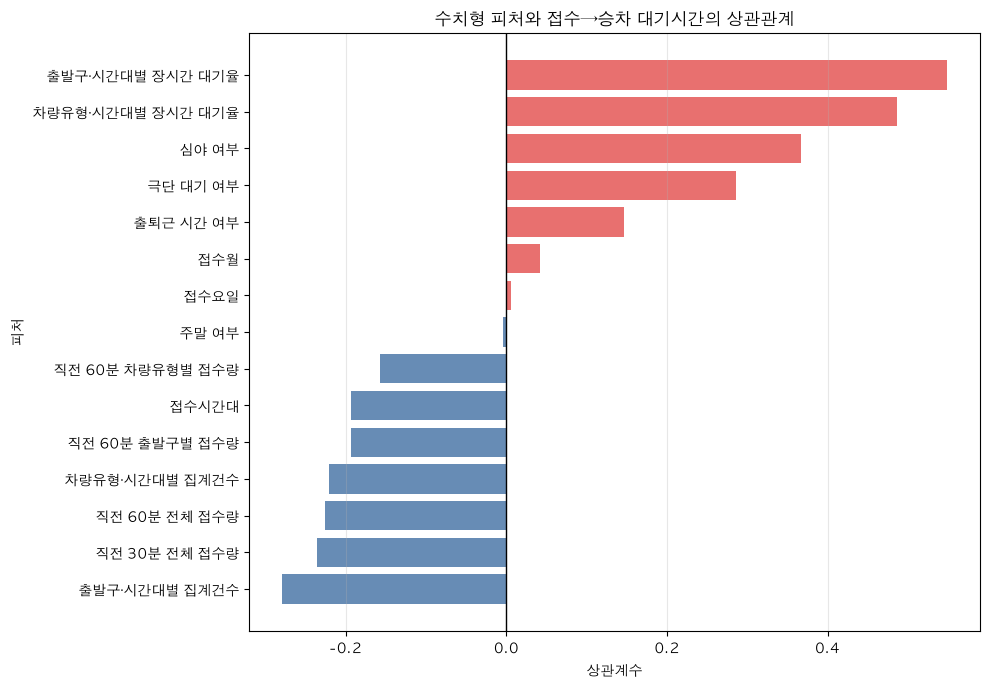

In [54]:
## 11-2. 상관계수 막대그래프
plt.figure(figsize=(10, 7))

plot_data = pearson_corr.sort_values("상관계수")

colors = plot_data["상관계수"].apply(
    lambda x: "#e45756" if x > 0 else "#4c78a8"
)

plt.barh(
    plot_data["피처"],
    plot_data["상관계수"],
    color=colors,
    alpha=0.85,
)

plt.axvline(0, color="black", linewidth=1)

plt.title("수치형 피처와 접수→승차 대기시간의 상관관계")
plt.xlabel("상관계수")
plt.ylabel("피처")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
## 11-3. Spearman 순위 상관계수 계산

spearman_corr = (
    corr_frame[corr_cols]
    .corr(method="spearman", numeric_only=True)["target_min"]
    .drop("target_min")
    .reset_index()
)

spearman_corr.columns = ["feature", "Spearman_상관계수"]
spearman_corr["피처"] = spearman_corr["feature"].map(feature_name_ko).fillna(spearman_corr["feature"])
spearman_corr["상관계수절댓값"] = spearman_corr["Spearman_상관계수"].abs()

spearman_corr = spearman_corr.sort_values("상관계수절댓값", ascending=False)

display(spearman_corr[["피처", "Spearman_상관계수"]].round(4))

,피처,Spearman_상관계수
11,출발구·시간대별 장시간 대기율,0.4859
12,차량유형·시간대별 장시간 대기율,0.4616
13,출발구·시간대별 집계건수,-0.3383
5,출퇴근 시간 여부,0.2566
10,직전 60분 출발구별 접수량,-0.2513
7,직전 30분 전체 접수량,-0.2352
4,심야 여부,0.2325
8,직전 60분 전체 접수량,-0.2177
14,차량유형·시간대별 집계건수,-0.2108
9,직전 60분 차량유형별 접수량,-0.1358


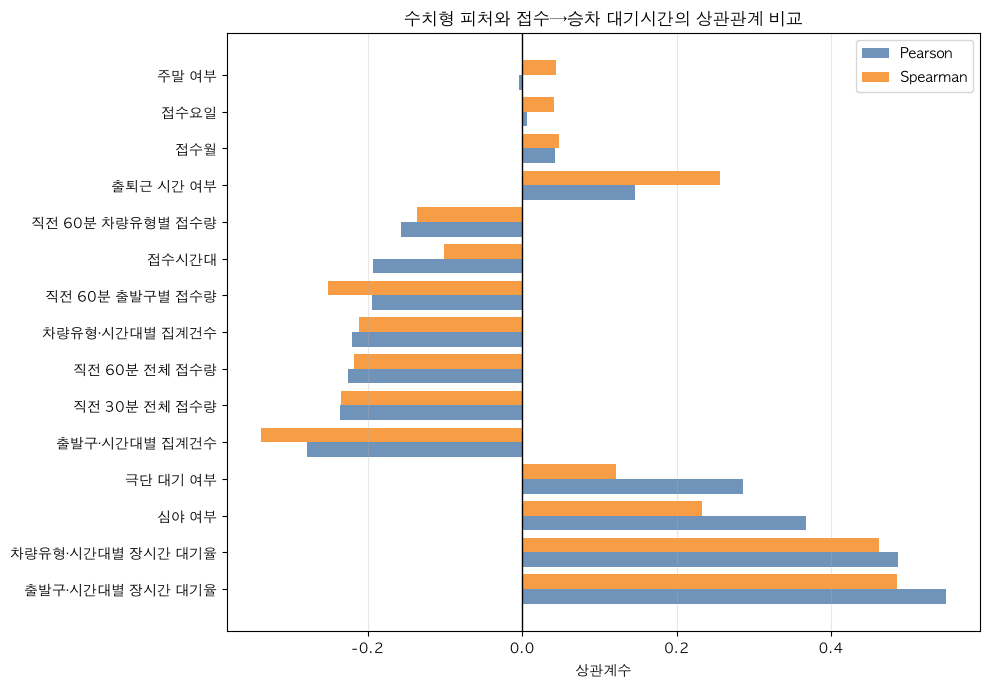

In [56]:
## 11-4. Pearson vs Spearman 비교 시각화

corr_compare = pearson_corr[["feature", "피처", "상관계수"]].merge(
    spearman_corr[["feature", "Spearman_상관계수"]],
    on="feature",
    how="left",
)

corr_compare = corr_compare.sort_values(
    "상관계수",
    key=lambda s: s.abs(),
    ascending=False,
)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(corr_compare))

ax.barh(
    y_pos - 0.2,
    corr_compare["상관계수"],
    height=0.4,
    label="Pearson",
    color="#4c78a8",
    alpha=0.8,
)

ax.barh(
    y_pos + 0.2,
    corr_compare["Spearman_상관계수"],
    height=0.4,
    label="Spearman",
    color="#f58518",
    alpha=0.8,
)

ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(corr_compare["피처"])
ax.set_xlabel("상관계수")
ax.set_title("수치형 피처와 접수→승차 대기시간의 상관관계 비교")
ax.grid(axis="x", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 12. RandomForest 하이퍼파라미터 재튜닝

기존 RandomForest 모델은 소규모 RandomizedSearch로 튜닝했으나, 장시간 대기 탐지 성능이 충분히 높지 않았다.  
따라서 현재 최종 피처 세트인 `수요 proxy + 장시간 대기율 proxy + 세부이동유형`을 기준으로, 기존 best parameter 주변을 좁혀 수동 GridSearch를 수행한다.

전체 `GridSearchCV`를 사용하면 데이터가 약 140만 건으로 커서 학습 시간이 과도하게 길어질 수 있다.  
따라서 train set으로 모델을 학습하고 validation set에서 직접 평가하는 방식으로 후보 조합을 비교한다.

튜닝 기준은 MAE만 보지 않고 다음 지표를 함께 확인한다.

```text
MAE
RMSE
R²
Recall
F1-score

In [57]:
from sklearn.model_selection import ParameterGrid

# 현재까지 가장 좋은 피처 세트
FINAL_FEATURES = MOVE_TYPE_FEATURES

# 기존 best 주변을 좁혀서 탐색
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [18, 22, 26],
    "min_samples_leaf": [5, 10, 20],
    "max_features": [0.8, 1.0],
}

grid = list(ParameterGrid(param_grid))

print(f"총 실험 조합 수: {len(grid)}")

grid_rows = []

for i, params in enumerate(grid, start=1):
    print(f"\n[{i}/{len(grid)}] params: {params}")

    model = build_rf_pipeline(
        FINAL_FEATURES,
        params,
    )

    model.fit(
        train_demand_rate[FINAL_FEATURES],
        train_demand_rate["target_min"],
    )

    valid_pred = model.predict(
        valid_demand_rate[FINAL_FEATURES]
    )

    reg = regression_metrics(
        valid_demand_rate["target_min"],
        valid_pred,
    )

    risk = risk_metrics(
        valid_demand_rate["target_min"].to_numpy(),
        valid_pred,
        long_wait_threshold,
    )

    grid_rows.append({
        "trial": i,
        **params,
        **reg,
        **{
            f"risk_{k}": v
            for k, v in risk.items()
            if k != "Confusion_Matrix"
        },
    })

grid_results = (
    pd.DataFrame(grid_rows)
    .sort_values(["MAE", "RMSE"])
    .reset_index(drop=True)
)

display(grid_results.round(4))

총 실험 조합 수: 36

[1/36] params: {'max_depth': 18, 'max_features': 0.8, 'min_samples_leaf': 5, 'n_estimators': 50}


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   25.8s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   33.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.3s finished



[2/36] params: {'max_depth': 18, 'max_features': 0.8, 'min_samples_leaf': 5, 'n_estimators': 100}


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   24.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.0min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.6s finished



[3/36] params: {'max_depth': 18, 'max_features': 0.8, 'min_samples_leaf': 10, 'n_estimators': 50}


...


[35/36] params: {'max_depth': 26, 'max_features': 1.0, 'min_samples_leaf': 20, 'n_estimators': 50}


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   35.2s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   46.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.4s finished



[36/36] params: {'max_depth': 26, 'max_features': 1.0, 'min_samples_leaf': 20, 'n_estimators': 100}


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   36.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.6min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


,trial,max_depth,max_features,min_samples_leaf,n_estimators,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,26,26,0.8,5,100,15.3092,9.9534,23.8207,0.5655,94.147,0.9301,0.7954,0.4038,0.5357
1,14,22,0.8,5,100,15.3251,9.9670,23.8774,0.5634,94.147,0.9297,0.7996,0.3952,0.5290
2,32,26,1.0,5,100,15.3480,9.9745,23.9031,0.5625,94.147,0.9300,0.7891,0.4083,0.5381
3,25,26,0.8,5,50,15.3549,9.9726,23.8784,0.5634,94.147,0.9297,0.7910,0.4025,0.5335
4,20,22,1.0,5,100,15.3574,9.9945,23.9467,0.5609,94.147,0.9298,0.7944,0.4010,0.5330
5,13,22,0.8,5,50,15.3653,9.9913,23.9264,0.5616,94.147,0.9294,0.7954,0.3946,0.5275
6,31,26,1.0,5,50,15.3922,9.9786,23.9614,0.5603,94.147,0.9297,0.7843,0.4087,0.5374
7,19,22,1.0,5,50,15.3953,9.9934,23.9977,0.5590,94.147,0.9295,0.7894,0.4015,0.5323
8,28,26,0.8,10,100,15.4755,10.0692,24.0791,0.5560,94.147,0.9288,0.7974,0.3851,0.5194
9,16,22,0.8,10,100,15.4931,10.0900,24.1189,0.5545,94.147,0.9284,0.7980,0.3786,0.5136


```text
MAE  약 0.48분 감소
RMSE 약 0.80분 감소
R²   0.532 → 0.566
Recall 0.354 → 0.404
F1   0.489 → 0.536

best_grid_params = {
    "max_depth": 26,
    "max_features": 0.8,
    "min_samples_leaf": 5,
    "n_estimators": 100,
}

트리를 깊게 만들고(max_depth=26),
잎 노드 최소 샘플을 작게 두고(min_samples_leaf=5),
각 분기에서 피처의 80%만 보게 해서(max_features=0.8),
트리는 100개 사용

## 13. train + valid 합쳐서 이 파라미터로 재학습
→ test set에서 최종 성능 확인

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

FINAL_FEATURES = [
    "model_group",
    "출발구",
    "목적구",
    "세부이동유형",
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "is_night",
    "is_commute",
    "request_count_prev_30m",
    "request_count_prev_60m",
    "model_group_request_count_prev_60m",
    "origin_gu_request_count_prev_60m",
    "origin_gu_hour_long_wait_rate",
    "model_group_hour_long_wait_rate",
]

def build_rf_pipeline(params=None):
    categorical_cols = [
        "model_group",
        "출발구",
        "목적구",
        "세부이동유형",
    ]

    numeric_cols = [
        "hour",
        "dayofweek",
        "month",
        "is_weekend",
        "is_night",
        "is_commute",
        "request_count_prev_30m",
        "request_count_prev_60m",
        "model_group_request_count_prev_60m",
        "origin_gu_request_count_prev_60m",
        "origin_gu_hour_long_wait_rate",
        "model_group_hour_long_wait_rate",
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
                categorical_cols,
            ),
            (
                "num",
                "passthrough",
                numeric_cols,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "n_estimators": 100,
        "max_depth": 26,
        "min_samples_leaf": 5,
        "max_features": 0.8,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbose": 1,
    }

    if params is not None:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(**default_params)),
    ])

In [60]:
best_grid_params = {
    "max_depth": 26,
    "max_features": 0.8,
    "min_samples_leaf": 5,
    "n_estimators": 100,
}

train_valid_final = pd.concat(
    [train_demand_rate, valid_demand_rate],
    ignore_index=True,
)

final_grid_model = build_rf_pipeline(best_grid_params)

final_grid_model.fit(
    train_valid_final[FINAL_FEATURES],
    train_valid_final["target_min"],
)

test_pred_final_grid = final_grid_model.predict(
    test_demand_rate[FINAL_FEATURES]
)

final_grid_test_metrics = evaluate_predictions(
    test_demand_rate,
    test_pred_final_grid,
    long_wait_threshold,
)

final_grid_test_metrics

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 56.0min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.6s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.5s finished


{'MAE': 15.055610308632861,
 'Median_AE': 9.764316812553945,
 'RMSE': np.float64(23.513429850874065),
 'R2': 0.5733889658795478,
 'risk_threshold': np.float64(94.14695333333344),
 'risk_Accuracy': 0.9318201231954898,
 'risk_Precision': 0.786926688335139,
 'risk_Recall': 0.42059547362833566,
 'risk_F1': 0.548193339413189,
 'risk_Confusion_Matrix': [[187639, 2360], [12007, 8716]]}

## 14. RandomForest 최종 GridSearch 모델 성능

RandomForest 하이퍼파라미터 튜닝 후 최종 모델을 train + validation 데이터로 재학습하고, test set에서 평가했다.

최종 모델 성능은 다음과 같다.

| 지표 | 값 |
|---|---:|
| MAE | 15.06분 |
| Median AE | 9.76분 |
| RMSE | 23.51분 |
| R² | 0.573 |
| 장시간 대기 Precision | 0.787 |
| 장시간 대기 Recall | 0.421 |
| 장시간 대기 F1 | 0.548 |

기존 최고 RandomForest 모델과 비교하면 MAE, RMSE, R²가 모두 개선되었고, 장시간 대기 위험 탐지 성능도 함께 좋아졌다.

| 모델 | MAE | RMSE | R² | Recall | F1 |
|---|---:|---:|---:|---:|---:|
| 기존 최고 RF | 15.7936 | 24.6245 | 0.5321 | 0.3541 | 0.4886 |
| GridSearch 최종 RF | 15.0556 | 23.5134 | 0.5734 | 0.4206 | 0.5482 |

특히 장시간 대기 Recall이 0.354에서 0.421로 상승했고, F1도 0.489에서 0.548로 개선되었다.  
이는 튜닝 전 모델보다 장시간 대기 위험을 더 잘 포착한다는 의미다.

다만 장시간 대기 실제 건 중 약 58%는 여전히 놓치고 있으므로, 네비게이터에서는 예측 대기시간 자체와 함께 위험 등급 또는 보수적인 경고 기준을 함께 사용하는 것이 적절하다.

Confusion Matrix는 다음과 같다.

```text
[[187639, 2360],
 [12007, 8716]]


## 15. 새벽 02~06시가 RandomForest 최종 모델 성능에 미치는 영향 점검

시간대별 분석에서 `02~06시`는 접수→승차 대기시간이 길고 장시간 대기 위험이 높은 구간으로 확인되었다.

다만 해당 시간대의 승차완료건수 비중은 전체에서 크지 않다.

```text
특장차 바로콜 02~06시 승차완료: 46,271건, 전체의 약 4.21%
임차택시 바로콜 02~06시 승차완료: 16,714건, 전체의 약 5.47%
```

따라서 이 섹션에서는 RandomForest 최종 모델 기준으로 다음을 비교한다.

```text
1. 전체 test 성능
2. 02~06시 test 성능
3. 02~06시 제외 test 성능
4. 02~06시 제외 시 장시간 대기 기준 재계산
5. 해석
```

목적은 새벽 시간대가 전체 모델의 MAE, RMSE, R²와 장시간 대기 risk 지표를 얼마나 흔드는지 확인하는 것이다.


In [ ]:

# 코드 셀 목적: RF 최종 모델의 test 예측값을 시간대 구간별로 평가한다.

if "test_pred_final_grid" not in globals():
    raise NameError(
        "test_pred_final_grid가 없습니다. "
        "먼저 RandomForest 최종 GridSearch 모델 예측 셀을 실행하세요."
    )

if "test_demand_rate" not in globals():
    raise NameError(
        "test_demand_rate가 없습니다. "
        "먼저 수요 proxy + 장시간 대기율 proxy + 세부이동유형 피처 생성 셀을 실행하세요."
    )


def evaluate_time_segment(frame, pred, threshold, label, mask):
    segment = frame.loc[mask].copy()
    segment_pred = np.asarray(pred)[mask]

    metrics = evaluate_predictions(
        segment,
        segment_pred,
        threshold,
    )

    return {
        "segment": label,
        "rows": len(segment),
        "rows_ratio(%)": len(segment) / len(frame) * 100,
        **{
            k: v
            for k, v in metrics.items()
            if k != "risk_Confusion_Matrix"
        },
        "risk_Confusion_Matrix": metrics["risk_Confusion_Matrix"],
    }


rf_test_frame = test_demand_rate.copy()
rf_test_pred = np.asarray(test_pred_final_grid)

mask_all = np.ones(len(rf_test_frame), dtype=bool)
mask_dawn = rf_test_frame["hour"].between(2, 6, inclusive="both").to_numpy()
mask_no_dawn = ~mask_dawn

rf_time_segment_results = pd.DataFrame([
    evaluate_time_segment(
        rf_test_frame,
        rf_test_pred,
        long_wait_threshold,
        "전체",
        mask_all,
    ),
    evaluate_time_segment(
        rf_test_frame,
        rf_test_pred,
        long_wait_threshold,
        "02~06시",
        mask_dawn,
    ),
    evaluate_time_segment(
        rf_test_frame,
        rf_test_pred,
        long_wait_threshold,
        "02~06시 제외",
        mask_no_dawn,
    ),
])

# 표를 보기 쉽게 주요 지표만 먼저 표시
rf_time_segment_display_cols = [
    "segment", "rows", "rows_ratio(%)",
    "MAE", "Median_AE", "RMSE", "R2",
    "risk_threshold", "risk_Accuracy", "risk_Precision", "risk_Recall", "risk_F1",
]

display(rf_time_segment_results[rf_time_segment_display_cols].round(4))

# Confusion Matrix는 별도로 확인
for _, row in rf_time_segment_results.iterrows():
    print(row["segment"], row["risk_Confusion_Matrix"])



## 15-1. 새벽 제외 시 장시간 대기 기준 재계산

위 평가는 기존 전체 train set 기준 장시간 대기 기준인 약 94.1분을 그대로 사용했다.

하지만 `02~06시`를 일반시간대와 분리한다면 장시간 대기 기준도 다시 계산해야 한다. 새벽 장시간 대기 패턴이 빠지면 90분위수 기준이 낮아질 수 있기 때문이다.

따라서 아래에서는 train set에서 `02~06시`를 제외한 뒤 전체 기준과 차량유형별 기준을 다시 계산한다.


In [ ]:

# 코드 셀 목적: 02~06시 제외 train set에서 장시간 대기 기준을 다시 계산한다.

train_no_dawn = train_demand_rate[
    ~train_demand_rate["hour"].between(2, 6, inclusive="both")
].copy()

test_no_dawn = rf_test_frame.loc[mask_no_dawn].copy()
test_pred_no_dawn = rf_test_pred[mask_no_dawn]

long_wait_threshold_no_dawn = train_no_dawn["target_min"].quantile(0.90)

threshold_by_group_no_dawn = (
    train_no_dawn.groupby("model_group")["target_min"]
    .quantile(0.90)
    .to_dict()
)

print("기존 전체 train p90 기준:", round(float(long_wait_threshold), 4))
print("02~06시 제외 train p90 기준:", round(float(long_wait_threshold_no_dawn), 4))
print()
print("기존 model_group별 p90 기준")
for k, v in threshold_by_group.items():
    print(k, round(float(v), 4))
print()
print("02~06시 제외 model_group별 p90 기준")
for k, v in threshold_by_group_no_dawn.items():
    print(k, round(float(v), 4))


In [ ]:

# 코드 셀 목적: 02~06시 제외 test set을 새로 계산한 장시간 대기 기준으로 다시 평가한다.

rf_no_dawn_rethreshold_metrics = evaluate_predictions(
    test_no_dawn,
    test_pred_no_dawn,
    long_wait_threshold_no_dawn,
)

rf_no_dawn_rethreshold_result = pd.DataFrame([
    {
        "segment": "02~06시 제외",
        "threshold_type": "기존 전체 p90 기준",
        **{
            k: v
            for k, v in rf_time_segment_results.loc[
                rf_time_segment_results["segment"].eq("02~06시 제외")
            ].iloc[0].to_dict().items()
            if k not in ["segment", "rows", "rows_ratio(%)", "risk_Confusion_Matrix"]
        },
    },
    {
        "segment": "02~06시 제외",
        "threshold_type": "02~06시 제외 p90 기준",
        **{
            k: v
            for k, v in rf_no_dawn_rethreshold_metrics.items()
            if k != "risk_Confusion_Matrix"
        },
    },
])

display(rf_no_dawn_rethreshold_result.round(4))

print("02~06시 제외 p90 기준 Confusion Matrix")
print(rf_no_dawn_rethreshold_metrics["risk_Confusion_Matrix"])



## 15-2. 해석 방향

결과는 다음 관점에서 해석한다.

1. `02~06시`의 MAE/RMSE가 전체보다 높다면, 새벽 시간대가 모델의 큰 오차에 영향을 주고 있다는 뜻이다.
2. `02~06시 제외`에서 MAE/RMSE가 개선되면, 일반시간대 모델은 새벽을 포함한 전체 모델보다 안정적으로 예측된다고 볼 수 있다.
3. `02~06시 제외 p90 기준`이 기존 전체 p90 기준보다 낮아지면, 기존 장시간 대기 기준은 새벽의 긴 대기시간에 의해 다소 높게 잡혔을 가능성이 있다.
4. 네비게이터 적용 시에는 새벽을 모델에서 제거하기보다 `새벽 위험 시간대 플래그`로 분리해 안내하는 것이 적절하다.

정리하면, 이 실험은 새벽시간대를 삭제하기 위한 것이 아니라 `일반시간대 예측 모델`과 `새벽 장시간 대기 위험 안내`를 분리할 필요가 있는지 확인하기 위한 것이다.
